In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\download\archive\american_bankruptcy.csv")

print("Original target:")
print(df["status_label"].value_counts())
df.head()

Original target:
status_label
alive     73462
failed     5220
Name: count, dtype: int64


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [26]:
df["status_label"] = (
    df["status_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [27]:
df["status_label"]  = df["status_label"].astype(str).str.strip().str.lower()
df["status_label"] = df["status_label"].map({
    "alive" :0,
    "failed" :1
})

df = df.dropna(subset=["status_label"])
X = df.drop(columns=["company_name", "status_label", "year"])
y = df["status_label"].astype(int)
X = X.apply(pd.to_numeric,errors="coerce")
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (78682, 18)
y shape: (78682,)

Class distribution:
status_label
0    73462
1     5220
Name: count, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("X_train_scaled:", X_train_scaled.shape)


X_train: (62945, 18)
X_test : (15737, 18)
X_train_scaled: (62945, 18)


In [29]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
logistic.fit(X_train_scaled, y_train)
print("Logistic Regression training!")


Logistic Regression training!


In [30]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split = 10,
    class_weight = "balanced",
    random_state = 42
)

tree.fit(X_train,y_train)
print("Decision Tree training!")

Decision Tree training!


In [31]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1 
) 

forest.fit(X_train,y_train)
print("Random Forest training!")

Random Forest training!


In [33]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=64,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

nn.fit(X_train_scaled, y_train)

print("Neural Network training completed!")

Neural Network training completed!


In [35]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    max_iter=100,
    batch_size=64,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2
)

nn.fit(X_train_scaled, y_train)

print("Neural Network training completed!")

Neural Network training completed!


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

# Logistic Regression
models = [
    ("Logistic Regression", logistic, X_test_scaled),
    ("Decision Tree", tree, X_test),
    ("Random Forest", forest, X_test)
]

for name, model, data in models:

    pred = model.predict(data)
    prob = model.predict_proba(data)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0),
        roc_auc_score(y_test, prob)
    ])

# Neural Network
nn_prob = nn.predict(X_test_scaled).ravel()
nn_pred = (nn_prob >= 0.5).astype(int)

results.append([
    "Neural Network",
    accuracy_score(y_test, nn_pred),
    precision_score(y_test, nn_pred, zero_division=0),
    recall_score(y_test, nn_pred, zero_division=0),
    f1_score(y_test, nn_pred, zero_division=0),
    roc_auc_score(y_test, nn_prob)
])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(
    "F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.773400,0.170757,0.626437,0.268363,0.797231
1,Decision Tree,0.671856,0.122849,0.642720,0.206271,0.703777
0,Logistic Regression,0.371291,0.084038,0.856322,0.153056,0.677968
3,Neural Network,0.934486,0.809524,0.016284,0.031925,0.508006


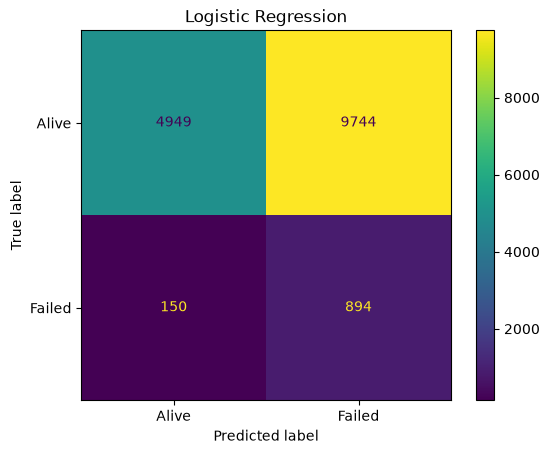

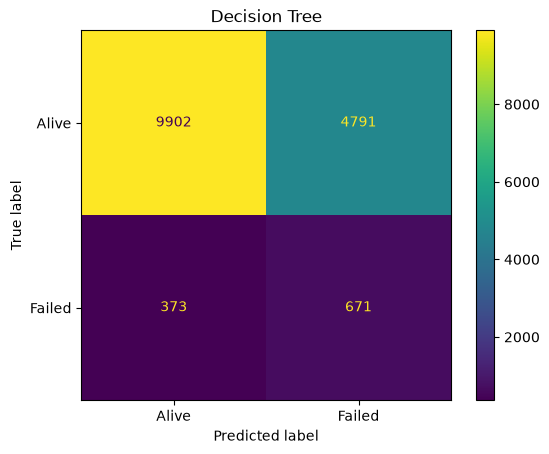

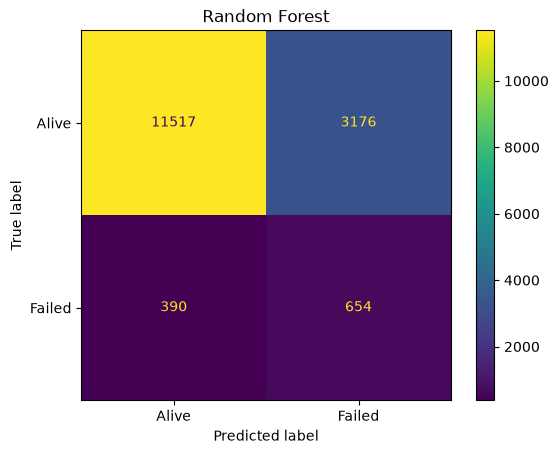

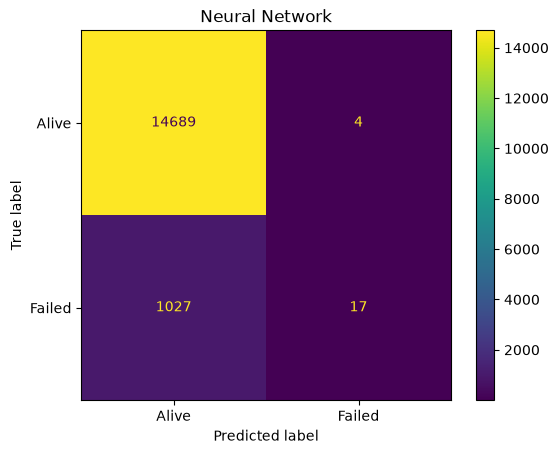

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    "Logistic Regression": logistic.predict(X_test_scaled),
    "Decision Tree": tree.predict(X_test),
    "Random Forest": forest.predict(X_test),
    "Neural Network": nn_pred
}

for name, pred in predictions.items():

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["Alive", "Failed"]
    )

    plt.title(name)
    plt.show()

In [1]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

NameError: name 'X_train' is not defined